In [1]:
data_folder = r"C:\Users\sanks\Downloads\training_data"

In [5]:
import pandas as pd
df = pd.read_csv(r"C:\Users\sanks\Downloads\training_data.csv")
print(df.columns)

Index(['Patient ID', 'Recording locations:', 'Age', 'Sex', 'Height', 'Weight',
       'Pregnancy status', 'Murmur', 'Murmur locations',
       'Most audible location', 'Systolic murmur timing',
       'Systolic murmur shape', 'Systolic murmur grading',
       'Systolic murmur pitch', 'Systolic murmur quality',
       'Diastolic murmur timing', 'Diastolic murmur shape',
       'Diastolic murmur grading', 'Diastolic murmur pitch',
       'Diastolic murmur quality', 'Outcome', 'Campaign', 'Additional ID'],
      dtype='object')


In [6]:
#df = df[df['Murmur'] != 'Unknown'].reset_index(drop=True)
df['Murmur'] = df['Murmur'].replace('Unknown', 'Absent')
print(df['Murmur'].value_counts())

Murmur
Absent     763
Present    179
Name: count, dtype: int64


In [2]:
import os
from collections import defaultdict

# Create a dictionary for patients
patients = defaultdict(lambda: {
    "wav": [],
    "hea": [],
    "tsv": [],
    "txt": None
})
# List all files
all_files = os.listdir(data_folder)

for file in all_files:

    # Ignore hidden/system files
    if file.startswith("."):
        continue
    file_path = os.path.join(data_folder, file)

    # Extract patient ID
    if "_" in file:
        patient_id = file.split("_")[0]
    else:
        patient_id = file.split(".")[0]
        
    if file.endswith(".wav"):
        patients[patient_id]["wav"].append(file_path)

    elif file.endswith(".hea"):
        patients[patient_id]["hea"].append(file_path)

    elif file.endswith(".tsv"):
        patients[patient_id]["tsv"].append(file_path)

    elif file.endswith(".txt"):
        patients[patient_id]["txt"] = file_path

patients = {int(k): v for k, v in patients.items()}

In [9]:
import pandas as pd

rows = []

for patient_id, files in patients.items():
    rows.append({
        "patient_id": patient_id,
        "num_wav": len(files["wav"]),
        "wav_files": files["wav"],
        "hea_files": files["hea"],
        "tsv_files": files["tsv"],
        "txt_file": files["txt"]
    })

df_patients = pd.DataFrame(rows)
df_patients["patient_id"] = df_patients["patient_id"].astype(int)
print(df_patients.head())

   patient_id  num_wav                                          wav_files  \
0       13918        4  [C:\Users\sanks\Downloads\training_data\13918_...   
1       14241        4  [C:\Users\sanks\Downloads\training_data\14241_...   
2       14998        4  [C:\Users\sanks\Downloads\training_data\14998_...   
3       23625        4  [C:\Users\sanks\Downloads\training_data\23625_...   
4       24160        4  [C:\Users\sanks\Downloads\training_data\24160_...   

                                           hea_files  \
0  [C:\Users\sanks\Downloads\training_data\13918_...   
1  [C:\Users\sanks\Downloads\training_data\14241_...   
2  [C:\Users\sanks\Downloads\training_data\14998_...   
3  [C:\Users\sanks\Downloads\training_data\23625_...   
4  [C:\Users\sanks\Downloads\training_data\24160_...   

                                           tsv_files  \
0  [C:\Users\sanks\Downloads\training_data\13918_...   
1  [C:\Users\sanks\Downloads\training_data\14241_...   
2  [C:\Users\sanks\Downloads\tra

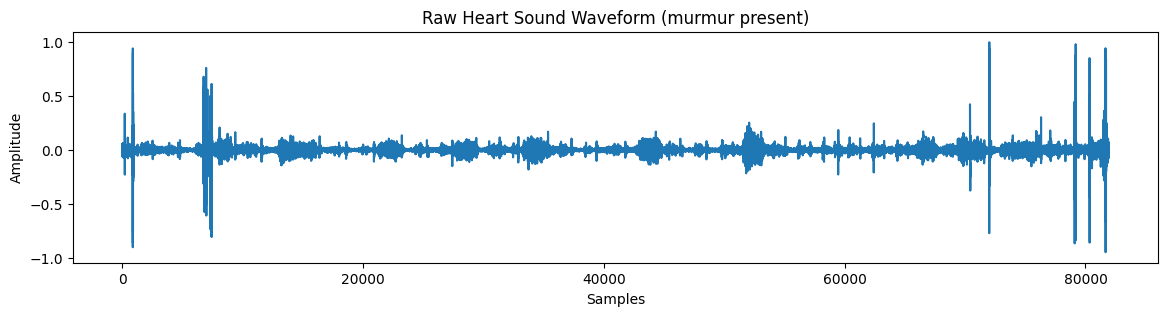

In [6]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

signal, sr = librosa.load(r'C:\Users\sanks\Downloads\training_data\14241_AV.wav', sr=4000)  # load your file
plt.figure(figsize=(14, 3))
plt.plot(signal)
plt.title("Raw Heart Sound Waveform (murmur present)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

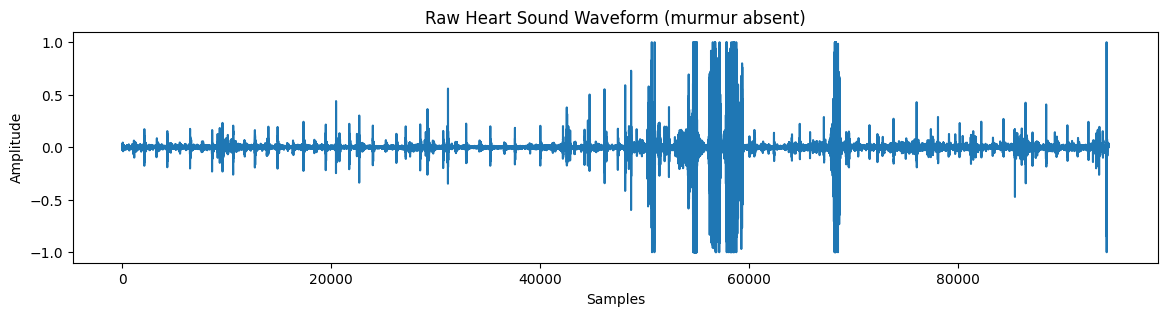

In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

signal, sr = librosa.load(r'C:\Users\sanks\Downloads\training_data\2530_AV.wav', sr=4000)  # load your file
plt.figure(figsize=(14, 3))
plt.plot(signal)
plt.title("Raw Heart Sound Waveform (murmur absent)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

train_ids, temp_ids= train_test_split(
    df["Patient ID"],
    test_size=0.30,
    stratify=df["Murmur"],
    random_state=37
)
test_ids, val_ids = train_test_split(
    temp_ids,
    test_size=0.5,
    stratify=df.loc[df["Patient ID"].isin(temp_ids), "Murmur"],
    random_state=37
)

In [10]:
df_train = df_patients[df_patients["patient_id"].isin(train_ids)]
df_val   = df_patients[df_patients["patient_id"].isin(val_ids)]
df_test  = df_patients[df_patients["patient_id"].isin(test_ids)]

In [11]:
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
import tensorflow as tf

In [ ]:
creating mel-spectrograms

In [16]:
def extract_logmel_segments(wav_path, segment_length=8, sr=4000):
    signal, _ = librosa.load(wav_path, sr=sr)
    segment_samples = segment_length * sr
    segments = []

    for start in range(0, len(signal) - segment_samples, segment_samples):
        segment = signal[start:start + segment_samples]
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=200,
            n_fft=1024,
            hop_length=200,
            fmin=20,
            fmax=1500)

        log_mel = librosa.power_to_db(mel)

        delta = librosa.feature.delta(log_mel)
        delta2 = librosa.feature.delta(log_mel, order=2)

        log_mel = np.stack([log_mel.T, delta.T, delta2.T], axis=-1)

        log_mel = (log_mel - np.mean(log_mel, axis=0)) / (np.std(log_mel, axis=0) + 1e-6)

        segments.append(log_mel)

    return segments

In [17]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder

def create_logmel_dataset(df_patients, df_labels, segment_length=6, sr=4000):

    VALID_POSITIONS = {"AV", "MV", "PV", "TV"}

    X = []
    y = []
    positions = []

    for _, row in df_patients.iterrows():

        patient_id = row["patient_id"]

        label_row = df_labels.loc[
            df_labels["Patient ID"] == patient_id,
            "Murmur"]

        if len(label_row) == 0:
            continue

        label = label_row.iloc[0]

        for wav_path in row["wav_files"]:

            filename = os.path.basename(wav_path)
            position = filename.split("_")[-1].replace(".wav", "")

            if position not in VALID_POSITIONS:
                continue

            segments = extract_logmel_segments(
                wav_path,
                segment_length=segment_length,
                sr=sr)

            if len(segments) == 0:
                continue

            X.extend(segments)
            y.extend([label] * len(segments))
            positions.extend([position] * len(segments))

    X = np.array(X)
    y = np.array(y)
    positions = np.array(positions)

    # Encode murmur labels
    le = LabelEncoder()
    y = le.fit_transform(y)

    return X, y, positions, le

In [18]:
X_train, y_train, pos_train, le = create_logmel_dataset(df_train, df)
X_val, y_val, pos_val, _ = create_logmel_dataset(df_val, df)
X_test, y_test, pos_test, _ = create_logmel_dataset(df_test, df)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (7224, 121, 200, 3)
Val shape: (1577, 121, 200, 3)
Test shape: (1548, 121, 200, 3)


In [19]:
import numpy as np
import matplotlib.pyplot as plt

idx_0 = np.where(y_train == 0)[0][0]
idx_1 = np.where(y_train == 1)[0][0]

mfcc_0 = X_train[idx_0].squeeze()
mfcc_1 = X_train[idx_1].squeeze()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.324169..3.2133453].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.9018002..3.564091].


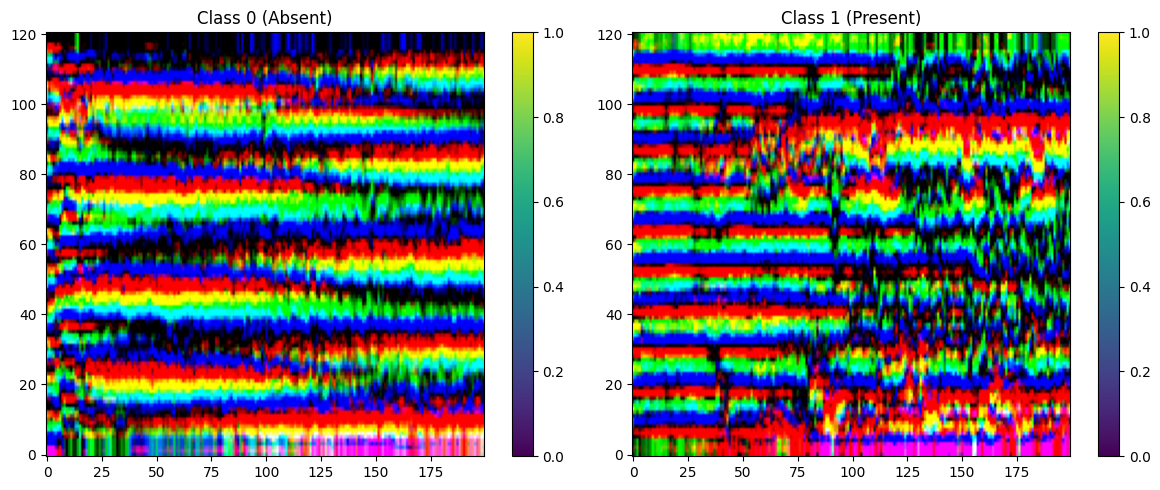

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Get first example of each class
idx_0 = np.where(y_train == 0)[0][0]
idx_1 = np.where(y_train == 1)[0][0]

mfcc_0 = X_train[idx_0].squeeze()
mfcc_1 = X_train[idx_1].squeeze()
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mfcc_0, aspect='auto', origin='lower') # Plotting the first channel (MFCCs)
plt.title("Class 0 (Absent)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(mfcc_1, aspect='auto', origin='lower') # Plotting the first channel (MFCCs)
plt.title("Class 1 (Present)")
plt.colorbar()

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
from sklearn.utils import resample

unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{0: 5904, 1: 1320}


In [22]:
import numpy as np
from sklearn.utils import resample

def oversample_arrays(X, y, pos, random_state=42):
    X_oversampled = []
    y_oversampled = []
    pos_oversampled = []

    classes = np.unique(y)
    max_count = max([np.sum(y == cls) for cls in classes])

    for cls in classes:
        X_cls = X[y == cls]
        y_cls = y[y == cls]
        pos_cls = pos[y == cls]

        X_resampled, y_resampled, pos_resampled = resample(
            X_cls,
            y_cls,
            pos_cls,
            replace=True,
            n_samples=max_count,
            random_state=random_state)

        X_oversampled.append(X_resampled)
        y_oversampled.append(y_resampled)
        pos_oversampled.append(pos_resampled)

    X_balanced = np.concatenate(X_oversampled, axis=0)
    y_balanced = np.concatenate(y_oversampled, axis=0)
    pos_balanced = np.concatenate(pos_oversampled, axis=0)

    idx = np.random.permutation(len(y_balanced))

    X_balanced = X_balanced[idx]
    y_balanced = y_balanced[idx]
    pos_balanced = pos_balanced[idx]

    return X_balanced, y_balanced, pos_balanced

In [23]:
X_train_bal, y_train_bal, pos_train_bal = oversample_arrays(X_train, y_train, pos = pos_train)

In [24]:
X_train_bal = X_train_bal.astype(np.float32)
X_val       = X_val.astype(np.float32)
X_test      = X_test.astype(np.float32)

In [25]:
y_train_cat = tf.keras.utils.to_categorical(y_train_bal, num_classes=2)
y_val_cat   = tf.keras.utils.to_categorical(y_val, num_classes=2)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes=2)

In [26]:
import numpy as np
import tensorflow as tf
from sklearn.utils import class_weight
from sklearn.metrics import precision_score, recall_score, f1_score


In [23]:
print(type(X_test))
print(X_test.shape)
print(X_test.dtype)

<class 'numpy.ndarray'>
(1548, 121, 200, 3)
float32


In [27]:
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from keras.utils import to_categorical

# Encode positions as integers
pos_encoder = LabelEncoder()
pos_train_enc = pos_encoder.fit_transform(pos_train_bal)
pos_val_enc   = pos_encoder.transform(pos_val)
pos_test_enc  = pos_encoder.transform(pos_test)

# One-hot encoding
num_positions = len(pos_encoder.classes_)

pos_train_ohe = to_categorical(pos_train_enc, num_positions)
pos_val_ohe   = to_categorical(pos_val_enc, num_positions)
pos_test_ohe  = to_categorical(pos_test_enc, num_positions)

In [28]:
class MetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val[..., np.newaxis]
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        precision = precision_score(self.y_val, y_pred, average='macro', zero_division=0)
        recall = recall_score(self.y_val, y_pred, average='macro', zero_division=0)
        f1 = f1_score(self.y_val, y_pred, average='macro', zero_division=0)
        print(f"Epoch {epoch+1} - Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

In [29]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.layers import Dropout, Input
from keras.optimizers import Adam

audio_input = layers.Input(shape=(121, 200, 3), name="audio_input")
pos_input = layers.Input(shape=(num_positions,), name="pos_input")

x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(audio_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

H, W, C = x.shape[1], x.shape[2], x.shape[3]
x = layers.Reshape((H, W*C))(x)

x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(32))(x)

p = layers.Dense(16, activation='relu')(pos_input)

combined = layers.Concatenate()([x, p])

combined = layers.Dense(64, activation='relu')(combined)
combined = layers.Dropout(0.4)(combined)

combined = layers.Dense(32, activation='relu')(combined)
combined = layers.Dropout(0.3)(combined)

output = layers.Dense(1, activation='sigmoid')(combined)

model = models.Model(inputs=[audio_input, pos_input], outputs=output)

loss = tf.keras.losses.BinaryFocalCrossentropy(
    alpha=0.75,
    gamma=2.0
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=loss,
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

model.summary()
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ audio_input (InputLayer)      │ (None, 121, 200, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 121, 200, 32)      │             896 │ audio_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 121, 200, 32)      │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 60, 100, 32)       │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 60, 100, 32)       │               0 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 60, 100, 64)       │          18,496 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 60, 100, 64)       │             256 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 30, 50, 64)        │               0 │ batch_normalization_1[0][… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 30, 50, 64)        │               0 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 30, 50, 64)        │          36,928 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 30, 50, 64)        │             256 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 15, 25, 64)        │               0 │ batch_normalization_2[0][… │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 15, 25, 64)        │               0 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 15, 1600)          │               0 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 15, 128)           │         852,48

 Total params: 958,033 (3.65 MB)

 Trainable params: 957,713 (3.65 MB)

 Non-trainable params: 320 (1.25 KB)

In [28]:
history = model.fit(
    [X_train_bal, pos_train_ohe],
    y_train_bal,
    validation_data=([X_val, pos_val_ohe], y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30


C:\Users\sanks\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['audio_input', 'pos_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


369/369 ━━━━━━━━━━━━━━━━━━━━ 484s 1s/step - accuracy: 0.5191 - auc: 0.5261 - loss: 0.1771 - precision: 0.5189 - recall: 0.5017 - val_accuracy: 0.1972 - val_auc: 0.7363 - val_loss: 0.2837 - val_precision: 0.1941 - val_recall: 1.0000
Epoch 2/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 452s 1s/step - accuracy: 0.6694 - auc: 0.7219 - loss: 0.1504 - precision: 0.7054 - recall: 0.5954 - val_accuracy: 0.5821 - val_auc: 0.8309 - val_loss: 0.2192 - val_precision: 0.3002 - val_recall: 0.8721
Epoch 3/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 0.7242 - auc: 0.7856 - loss: 0.1352 - precision: 0.7891 - recall: 0.6106 - val_accuracy: 0.7495 - val_auc: 0.8545 - val_loss: 0.1828 - val_precision: 0.4224 - val_recall: 0.8033
Epoch 4/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.7396 - auc: 0.8012 - loss: 0.1304 - precision: 0.8269 - recall: 0.6103 - val_accuracy: 0.7812 - val_auc: 0.8652 - val_loss: 0.1651 - val_precision: 0.4618 - val_recall: 0.7934
Epoch 5/30
369/369 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
model.save(r"C:\Users\sanks\Downloads\heart_murmur_models\gru_model.h5")

In [30]:
results = model.evaluate(
    [X_val, pos_val_ohe],}
    y_val,
    batch_size=64,
    verbose=1
)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test AUC:", results[2])

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step - accuracy: 0.7300 - auc: 0.8829 - loss: 0.2121 - precision: 0.4286 - recall: 0.8715
Test Loss: 0.20500800013542175
Test Accuracy: 0.7412809133529663
Test AUC: 0.878182053565979


In [31]:
from sklearn.metrics import roc_curve
y_pred_prob = model.predict([X_test, pos_test_ohe])
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]

print("Best threshold (Youden):", best_threshold)

49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step
Best threshold (Youden): 0.76375425


In [ ]:
y_pred = (y_pred_prob > 0.55).astype(int).flatten()

In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("confusion_matrix:\n")
print(cm)


Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.76      0.84      1247
           1       0.44      0.77      0.56       301

    accuracy                           0.76      1548
   macro avg       0.68      0.76      0.70      1548
weighted avg       0.84      0.76      0.78      1548

confusion_matrix:

[[949 298]
 [ 70 231]]


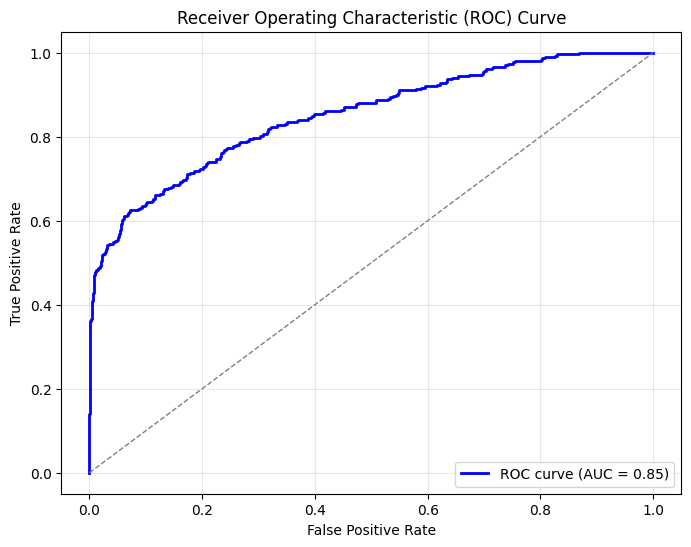

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

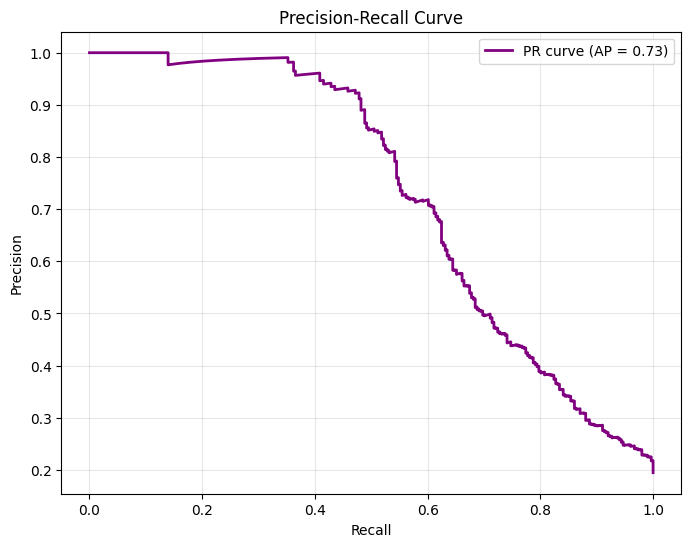

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

avg_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()